# Model 2 — Full Model, Custom Movement, No Temperature

This notebook adds **adult movement** to the baseline ATV model while still keeping **temperature turned off**.

It keeps:
- offspring: `S`, `I`
- adults: `R_a`, `R_c`
- maturation
- environmental transmission
- cross-strata force of infection
- **custom centroid-based adult movement**

It uses a **kernel-allocated birth workaround**:
- adult movement is still simulated with `CustomCentroids()`
- births are **not** booked to the moving adults' home ponds
- instead, births are allocated to **destination ponds** using the same distance kernel used for movement

So this version is meant to answer: **does the disease model still behave sensibly with movement present, while offspring remain attributed to the pond they are born in?**


In [1]:
# =====================
# Imports and SSL Setup
# =====================

import certifi
import os
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
os.environ["SSL_CERT_FILE"] = certifi.where()

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from epymorph.kit import *  # noqa
from epymorph.data_type import CentroidDType
from pathlib import Path
from sympy import Max
from CustomMovement import CustomCentroids

from epymorph.util import pairwise_haversine, row_normalize

from datetime import date
from epymorph.adrio import us_tiger, prism as prism_adrio


In [2]:
# ==========================================
# Load Temperature Data (PRISM)
# ==========================================
# Epymorph handles caching internally — data is only downloaded once.

coconino_scope = CountyScope.in_counties(["04005"], year=2020)
temp_time_frame = TimeFrame.range(date(2020, 1, 1), date(2020, 12, 31))

mean_temp_adrio = prism_adrio.Temperature("Mean")

with sim_messaging(live=False):
    temperature_data = mean_temp_adrio.with_context(
        scope=coconino_scope,
        time_frame=temp_time_frame,
        params={"centroid": us_tiger.GeometricCentroid()},
    ).evaluate()

daily_temps = temperature_data[:, 0]

print(f"Temperature — Min: {daily_temps.min():.1f}°C, Max: {daily_temps.max():.1f}°C")

Temperature — Min: -8.6°C, Max: 24.9°C


In [3]:
# =====================
# Load Custom Pond Data
# =====================

try:
    current_dir = Path(__file__).resolve().parent
except NameError:
    current_dir = Path().resolve().parent

test_data_path = current_dir / "data" / "basicTestData.csv"
df = pd.read_csv(test_data_path)

site_ids = df["site_id"].astype(str).tolist()
scope = CustomScope(site_ids)

total_pop = np.array(df["n_salamanders"].tolist(), dtype=int)

seed_location_index = 2
seed_size = int(df.loc[seed_location_index, "initial_infected"])

time = TimeFrame.of("2020-01-01", duration_days=365)

adult_frac = 0.40
adult_pop = np.floor(total_pop * adult_frac).astype(int)
offspring_pop = (total_pop - adult_pop).astype(int)

print("Sites:", site_ids)
print("Adult population by pond:", adult_pop)
print("Seed location index:", seed_location_index)
print("Seed size:", seed_size)

lon = df["lon"].astype(float).to_numpy()
lat = df["lat"].astype(float).to_numpy()

coords = np.array(list(zip(lon,lat)), dtype=CentroidDType)

n_nodes = len(site_ids)
sim_days = time.duration_days


Sites: ['Pond_A', 'Pond_B', 'Pond_C']
Adult population by pond: [40 30 56]
Seed location index: 2
Seed size: 14


In [4]:
# ========================
# Seasonal timing settings
# ========================

season_start = 135  # May 15
season_end = 258    # September 15

In [5]:
# ==========================================
# Kernel helpers for movement-aligned births
# ==========================================

def offdiag_kernel_from_coords(coords: np.ndarray, phi: float) -> np.ndarray:
    """Distance kernel with self-movement removed and rows renormalized."""
    distance = pairwise_haversine(coords)
    kernel = row_normalize(1 / np.exp(distance / phi))
    kernel = kernel.copy()
    np.fill_diagonal(kernel, 0.0)
    row_sums = kernel.sum(axis=1, keepdims=True)
    # avoid divide-by-zero for degenerate rows
    kernel = np.divide(kernel, row_sums, out=np.zeros_like(kernel), where=row_sums > 0)
    return kernel

def effective_breeding_kernel(coords: np.ndarray, phi: float, move_prop: float) -> np.ndarray:
    """Mix staying-home breeders with away breeders drawn from the movement kernel."""
    k_offdiag = offdiag_kernel_from_coords(coords, phi)
    ident = np.eye(k_offdiag.shape[0], dtype=float)
    return (1.0 - move_prop) * ident + move_prop * k_offdiag


In [6]:
# ================================
# Offspring IPM: S, I + deaths
# ================================

class OffspringSI(CompartmentModel):
    compartments = [
        compartment("S", "susceptible offspring"),
        compartment("I", "infected offspring"),
    ]

    requirements = [
        AttributeDef("beta", type=float, shape=Shapes.TxN,
                     comment="offspring transmission rate"),
        AttributeDef("death_rate", type=float, shape=Shapes.TxN,
                     comment="offspring natural mortality rate"),
        AttributeDef("disease_death_rate", type=float, shape=Shapes.TxN,
                     comment="non-temperature disease mortality on infected offspring"),
    ]

    def edges(self, symbols: ModelSymbols) -> list[TransitionDef]:
        S, I = symbols.all_compartments
        beta, mu, disease_death_rate = symbols.all_requirements

        N = Max(1, S + I)

        return [
            edge(S, I, rate=beta * S * I / N),
            edge(S, DEATH, rate=mu * S),
            edge(I, DEATH, rate=mu * I),
            edge(I, DEATH, rate=disease_death_rate * I),
        ]

In [7]:
# ================================================
# Adult IPM: R_a (cleared), R_c (chronic carrier)
# ================================================

class AdultRaRc(CompartmentModel):
    compartments = [
        compartment("R_a", "cleared adult salamanders"),
        compartment("R_c", "chronic carrier adult salamanders"),
    ]

    requirements = [
        AttributeDef("death_rate", type=float, shape=Shapes.TxN,
                     comment="adult natural mortality rate"),
        AttributeDef("beta_adult", type=float, shape=Shapes.TxN,
                     comment="adult-to-adult horizontal transmission rate"),
    ]

    def edges(self, symbols: ModelSymbols) -> list[TransitionDef]:
        R_a, R_c = symbols.all_compartments
        mu, beta_adult = symbols.all_requirements

        N_adult = Max(1, R_a + R_c)

        return [
            edge(R_a, R_c, rate=beta_adult * R_a * R_c / N_adult),
            edge(R_a, DEATH, rate=mu * R_a),
            edge(R_c, DEATH, rate=mu * R_c),
        ]

In [8]:
# ============================
# Multi-Strata Model Builder
# ============================

class SIR_Move_Temp(MultiStrataRUMEBuilder):
    def __init__(self):
        self.strata = [
            GPM(
                name="offspring",
                ipm=OffspringSI(),
                mm=mm.No(),
                init=init.NoInfection(),
            ),
            GPM(
                name="adult",
                ipm=AdultRaRc(),
                mm=CustomCentroids(),
                init=init.SingleLocation(
                    initial_compartment="R_a",
                    infection_compartment="R_c",
                    location=seed_location_index,
                    seed_size=seed_size,
                ),
            ),
        ]

        self.meta_requirements = [
            AttributeDef("mature_rate", type=float, shape=Shapes.TxN,
                         comment="end of season maturation rate"),
            AttributeDef("birth_rate", type=float, shape=Shapes.TxN,
                         comment="absolute births per node per day after kernel allocation"),
            AttributeDef("p_chronic", type=float, shape=Shapes.TxN,
                         comment="probability infected offspring become chronic carriers on maturation"),
            AttributeDef("p_disease_death", type=float, shape=Shapes.TxN,
                         comment="probability infected offspring die from disease on maturation"),
            AttributeDef("beta_env", type=float, shape=Shapes.TxN,
                         comment="environmental transmission from chronic adults to offspring"),
            AttributeDef("beta_force", type=float, shape=Shapes.TxN,
                         comment="cross-strata force of infection from infected offspring to adults"),
        ]

    def meta_edges(self, symbols: MultiStrataModelSymbols) -> list[TransitionDef]:
        S, I = symbols.strata_compartments("offspring")
        R_a, R_c = symbols.strata_compartments("adult")

        mature_rate, birth_rate, p_chronic, p_disease_death, beta_env, beta_force = symbols.all_meta_requirements

        N_offspring = Max(1, S + I)
        N_adult = Max(1, R_a + R_c)

        return [
            edge(S, R_a, rate=mature_rate * S),

            fork(
                edge(I, DEATH, rate=p_disease_death * mature_rate * I),
                edge(I, R_c, rate=p_chronic * mature_rate * I),
                edge(I, R_a, rate=(1 - p_chronic) * mature_rate * I),
            ),

            edge(BIRTH, S, rate=birth_rate),

            edge(S, I, rate=beta_env * S * R_c / N_offspring),

            edge(R_a, R_c, rate=beta_force * R_a * I / N_adult),
        ]

In [44]:
# =========================================
# Temperature-aware seasonal parameter fns
# =========================================

phi_value = 5.0
movement_prop_value = 1.0

class SeasonalBeta(ParamFunctionTimeAndNode):
    def __init__(self, temps: np.ndarray):
        self.temps = temps

    def evaluate1(self, day: int, node_index: int) -> float:
        beta_max = 0.000187
        beta_off = 0.0
        t_mod = day % 365

        temp = self.temps[t_mod]
        optimal_temp = 22.0
        sigma = 5.0
        beta_scaled = beta_max * np.exp(-((temp - optimal_temp) ** 2) / (2 * sigma ** 2))
        return float(beta_scaled)


class SeasonalAdultBeta(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        beta_adult_on = 0.005
        t_mod = day % 365
        if season_start <= t_mod <= season_end:
            return beta_adult_on
        return 0.0


class KernelAllocatedBirths(ParamFunctionTimeAndNode):
    """Allocate births to destination ponds using the movement kernel.

    This avoids the 'tourist birth' bookkeeping artifact where offspring
    follow the home pond of a moving adult. Instead, births are assigned to the
    pond where breeders are expected to be present.
    """

    dtype = float

    def evaluate1(self, day: int, node_index: int) -> float:
        t_mod = day % 365
        if not (season_start <= t_mod <= season_start + 7):
            return 0.0

        k_eff = effective_breeding_kernel(coords, phi_value, movement_prop_value)
        breeders_present = adult_pop.astype(float) @ k_eff

        birth_season = 1 / 12
        return float(birth_season * breeders_present[node_index])


class SeasonalDeaths(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        winter = 1 / 365
        summer = 1 / (365 * 3)
        t_mod = day % 365
        if t_mod >= season_end or t_mod < season_start:
            return winter
        return summer


class TempDependentMortality(ParamFunctionTimeAndNode):
    def __init__(self, temps: np.ndarray):
        self.temps = temps

    def evaluate1(self, day: int, node_index: int) -> float:
        t_mod = day % 365

        temp = self.temps[t_mod]
        peak_temp = 22.0
        sigma_cold = 4.0
        sigma_warm = 8.0
        mortality_max = 1.5 / 365

        if temp <= peak_temp:
            return float(mortality_max * np.exp(-((temp - peak_temp) ** 2) / (2 * sigma_cold ** 2)))
        else:
            return float(mortality_max * np.exp(-((temp - peak_temp) ** 2) / (2 * sigma_warm ** 2)))


class SeasonalMaturation(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        t_mod = day % 365
        if season_end - 1 <= t_mod <= season_end + 2:
            return 1.0
        return 0.0


class SeasonalMovementProportion(ParamFunctionTimeAndNode):
    def evaluate1(self, day: int, node_index: int) -> float:
        move_on = movement_prop_value
        move_off = 0.0
        t_mod = day % 365
        if season_start <= t_mod <= season_start + 14:
            return move_on
        return move_off

In [45]:
# ================
# Build the RUME
# ================

rume = SIR_Move_Temp().build(
    scope=scope,
    time_frame=time,
    params={
        # Offspring IPM params
        "gpm:offspring::ipm::beta": SeasonalBeta(daily_temps),
        "gpm:offspring::ipm::death_rate": SeasonalDeaths(),
        "gpm:offspring::ipm::disease_death_rate": TempDependentMortality(daily_temps),

        # Adult IPM params
        "gpm:adult::ipm::death_rate": SeasonalDeaths(),
        "gpm:adult::ipm::beta_adult": SeasonalAdultBeta(),


        # Adult movement params
        "gpm:adult::mm::population": adult_pop,
        "gpm:adult::mm::centroid": coords,
        "gpm:adult::mm::phi": phi_value,
        "gpm:adult::mm::commuter_proportion": SeasonalMovementProportion(),

        # Meta params
        "meta::ipm::mature_rate": SeasonalMaturation(),
        "meta::ipm::birth_rate": KernelAllocatedBirths(),
        "meta::ipm::p_chronic": 0.4,
        "meta::ipm::p_disease_death": 0.20,
        "meta::ipm::beta_env": 0.1,
        "meta::ipm::beta_force": 0.01,

        # Populations per strata
        "gpm:offspring::init::population": 0,
        "gpm:adult::init::population": adult_pop.tolist(),
    },
)

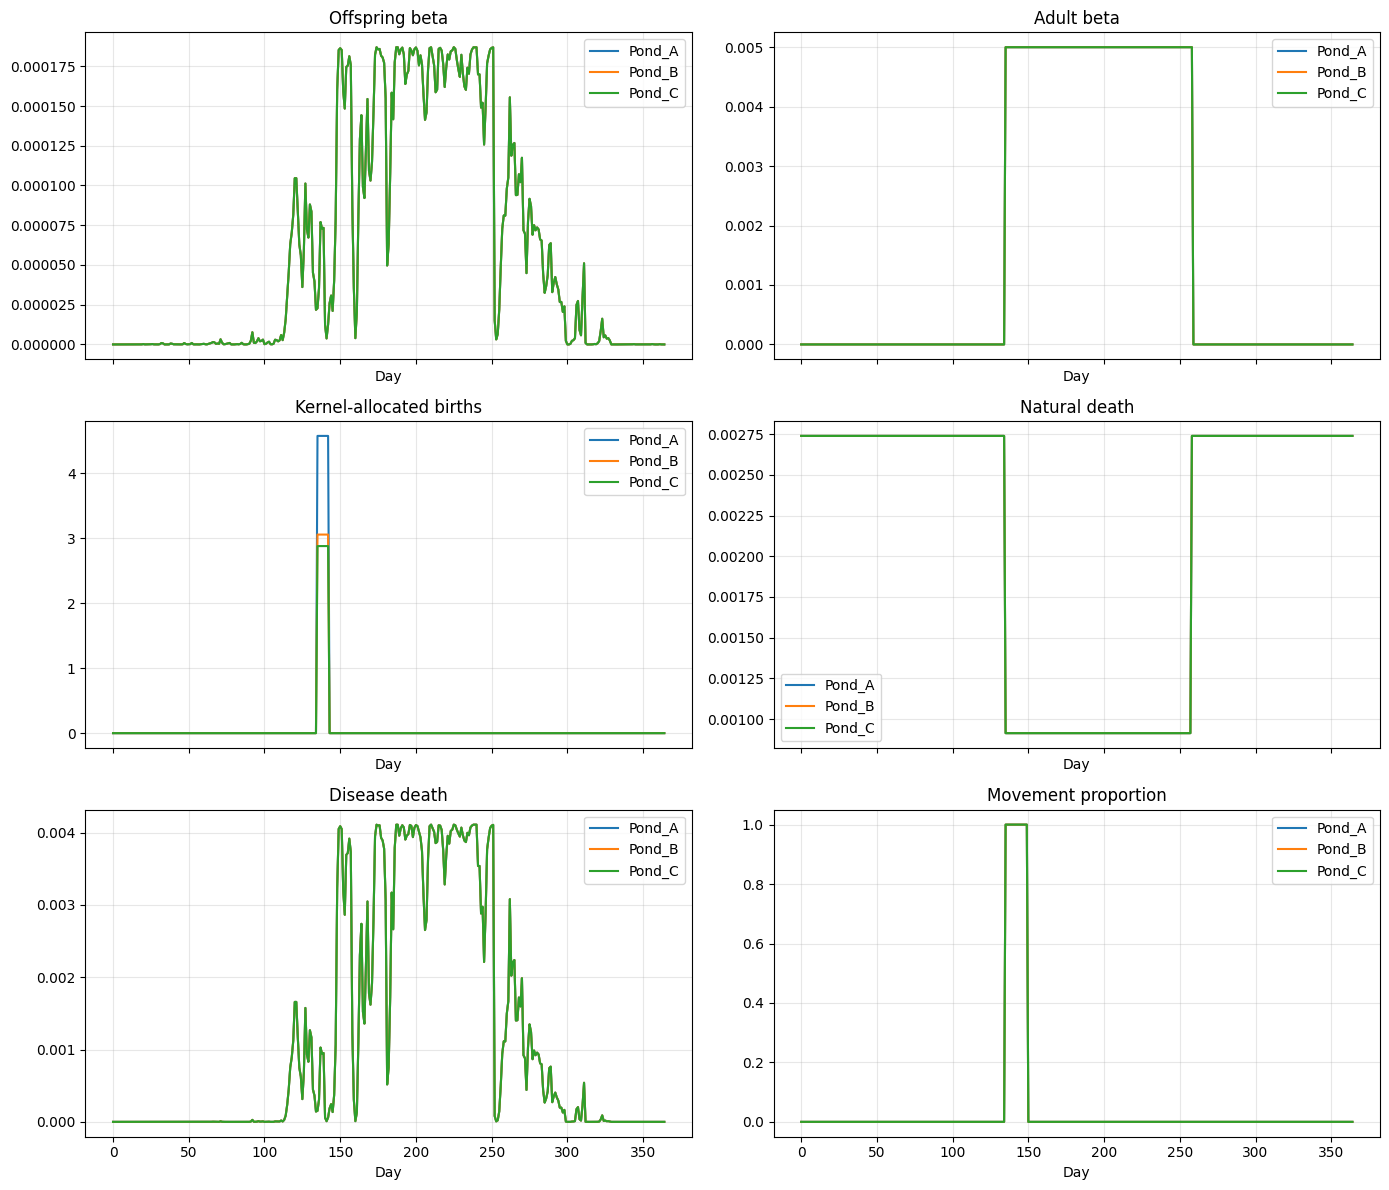

Effective breeding kernel (rows = home pond, cols = birth pond):
        Pond_A  Pond_B  Pond_C
Pond_A   0.000   0.437   0.563
Pond_B   0.600   0.000   0.400
Pond_C   0.658   0.342   0.000

Expected breeders present by destination pond:
Pond_A    54.84
Pond_B    36.64
Pond_C    34.52
dtype: float64


In [46]:
# =====================
# Parameter diagnostics
# =====================

beta_values = SeasonalBeta(daily_temps).with_context(scope=rume.scope, time_frame=rume.time_frame).evaluate()
beta_adult_values = SeasonalAdultBeta().with_context(scope=rume.scope, time_frame=rume.time_frame).evaluate()
birth_values = KernelAllocatedBirths().with_context(scope=rume.scope, time_frame=rume.time_frame).evaluate()
death_values = SeasonalDeaths().with_context(scope=rume.scope, time_frame=rume.time_frame).evaluate()
disease_death_values = TempDependentMortality(daily_temps).with_context(scope=rume.scope, time_frame=rume.time_frame).evaluate()
maturation_values = SeasonalMaturation().with_context(scope=rume.scope, time_frame=rume.time_frame).evaluate()
move_values = SeasonalMovementProportion().with_context(scope=rume.scope, time_frame=rume.time_frame).evaluate()

birth_kernel = effective_breeding_kernel(coords, phi_value, movement_prop_value)
expected_breeders_present = adult_pop.astype(float) @ birth_kernel

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for i, pond in enumerate(site_ids):
    axes[0].plot(beta_values[:, i], label=pond)
    axes[1].plot(beta_adult_values[:, i], label=pond)
    axes[2].plot(birth_values[:, i], label=pond)
    axes[3].plot(death_values[:, i], label=pond)
    axes[4].plot(disease_death_values[:, i], label=pond)
    axes[5].plot(move_values[:, i], label=pond)

axes[0].set_title("Offspring beta")
axes[1].set_title("Adult beta")
axes[2].set_title("Kernel-allocated births")
axes[3].set_title("Natural death")
axes[4].set_title("Disease death")
axes[5].set_title("Movement proportion")

for ax in axes:
    ax.grid(alpha=0.3)
    ax.set_xlabel("Day")
    ax.legend()

plt.tight_layout()
plt.show()

print("Effective breeding kernel (rows = home pond, cols = birth pond):")
print(pd.DataFrame(birth_kernel, index=site_ids, columns=site_ids).round(3))
print("\nExpected breeders present by destination pond:")
print(pd.Series(expected_breeders_present, index=site_ids).round(2))


In [47]:
# ==================
# Run the Simulation
# ==================

sim = BasicSimulator(rume)
rng_seed = 5

with sim_messaging(live=False):
    out = sim.run(rng_factory=default_rng(rng_seed))

df_out = out.dataframe
df_out["day"] = df_out["tick"] / 2
ponds = out.rume.scope.node_ids

print(df_out.head())

Running simulation (BasicSimulator):
• 2020-01-01 to 2020-12-30 (365 days)
• 3 geo nodes

DAY 135, STEP 0
pop: [40 30 56]
comm_prop: [1. 1. 1.]
n_commuters: [40 30 56]
kernel:
 [[0.         0.43743603 0.56256397]
 [0.59954586 0.         0.40045414]
 [0.65816952 0.34183048 0.        ]]
movers matrix:
 [[ 0 19 21]
 [17  0 13]
 [39 17  0]]
row sums: [40 30 56]
  |####################| 100% 
Runtime: 1.248s
   tick       date    node  S_offspring  I_offspring  R_a_adult  R_c_adult  \
0     0 2020-01-01  Pond_A            0            0         40          0   
1     0 2020-01-01  Pond_B            0            0         30          0   
2     0 2020-01-01  Pond_C            0            0         42         14   
3     1 2020-01-01  Pond_A            0            0         40          0   
4     1 2020-01-01  Pond_B            0            0         30          0   

   S_offspring → I_offspring  S_offspring → death_exogenous  \
0                          0                              0  

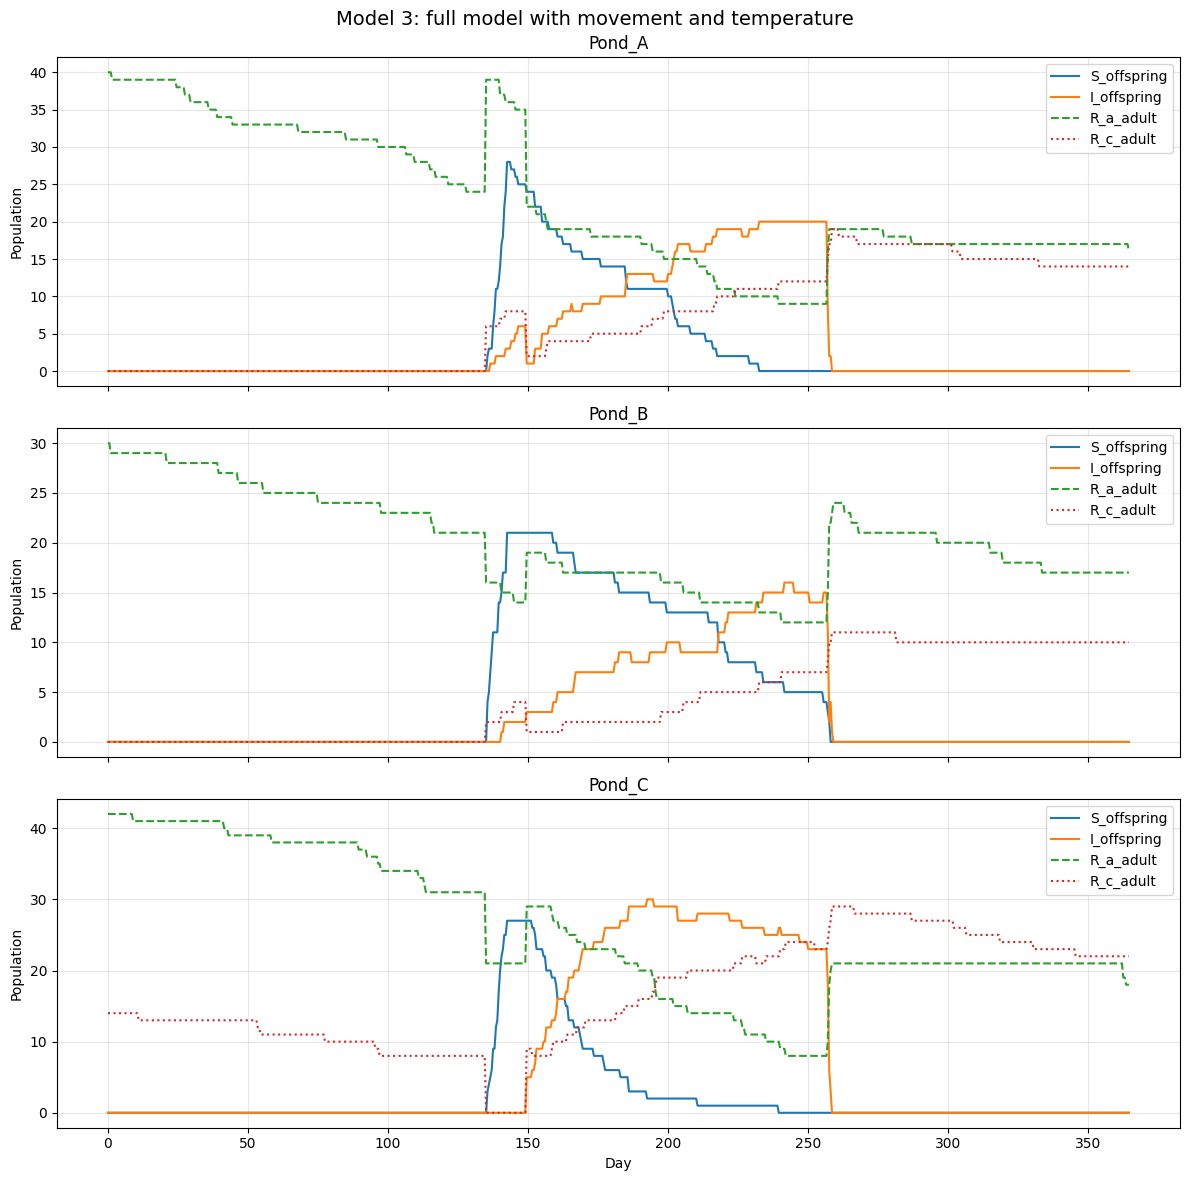

In [48]:
# ========================
# Plot simulation by pond
# ========================

fig, axes = plt.subplots(len(ponds), 1, figsize=(12, 4 * len(ponds)), sharex=True)

if len(ponds) == 1:
    axes = [axes]

for ax, pond in zip(axes, ponds):
    pond_df = df_out[df_out["node"] == pond]
    ticks = pond_df["day"].to_numpy()

    ax.plot(ticks, pond_df["S_offspring"].to_numpy(), label="S_offspring")
    ax.plot(ticks, pond_df["I_offspring"].to_numpy(), label="I_offspring")
    ax.plot(ticks, pond_df["R_a_adult"].to_numpy(), label="R_a_adult", linestyle="--")
    ax.plot(ticks, pond_df["R_c_adult"].to_numpy(), label="R_c_adult", linestyle=":")

    ax.set_title(f"{pond}")
    ax.set_ylabel("Population")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Day")
plt.suptitle("Model 3: full model with movement and temperature", fontsize=14)
plt.tight_layout()
plt.show()

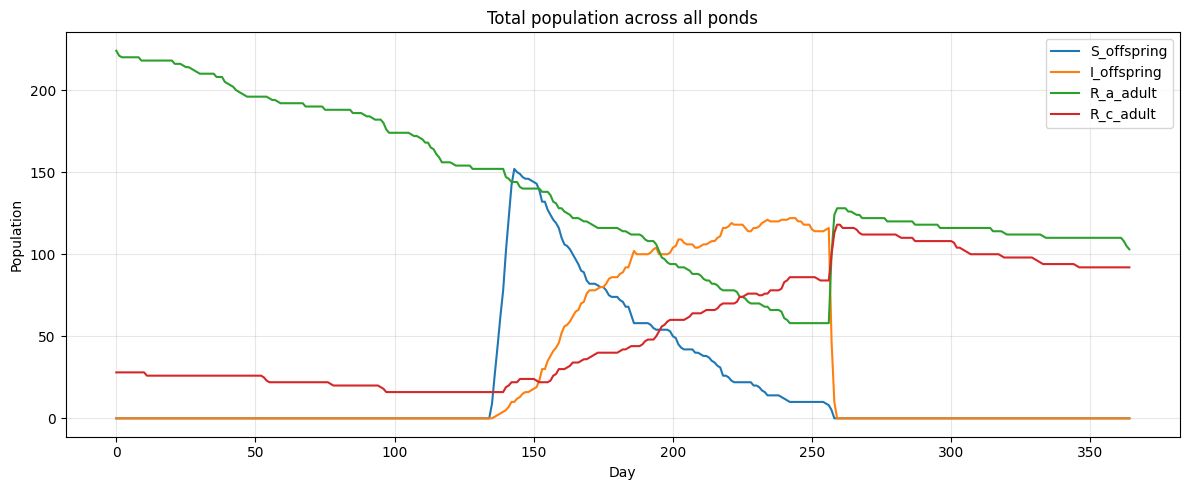

In [49]:
# =======================
# Plot total populations
# =======================

totals = df_out.assign(day=df_out["tick"] // 2).groupby("day")[["S_offspring", "I_offspring", "R_a_adult", "R_c_adult"]].sum()

fig, ax = plt.subplots(figsize=(12, 5))
for col in totals.columns:
    ax.plot(totals.index, totals[col], label=col)

ax.set_title("Total population across all ponds")
ax.set_xlabel("Day")
ax.set_ylabel("Population")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

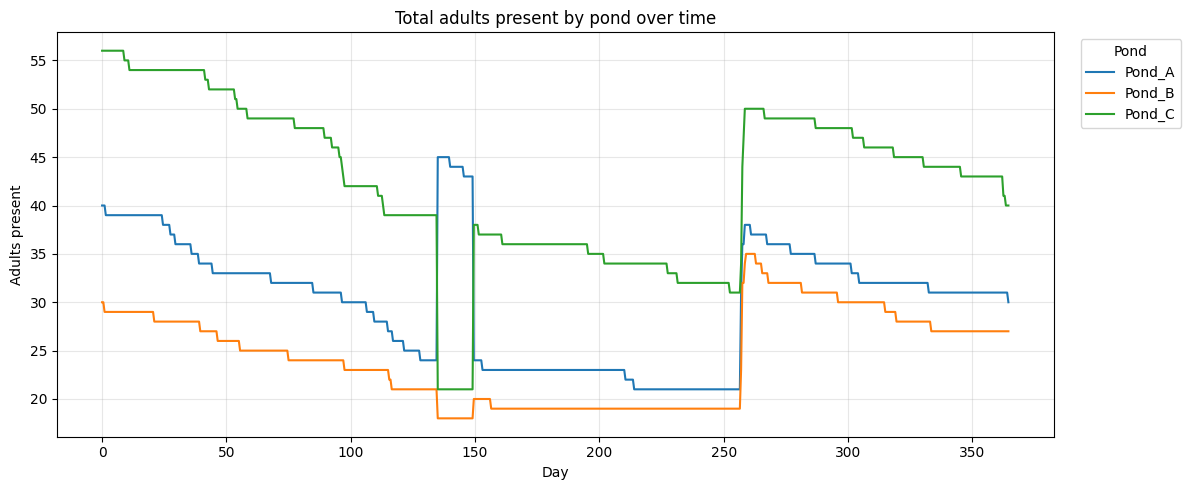

In [50]:
# =========================================
# Compare adult burden across ponds over time
# =========================================

adult_totals_by_pond = (
    df_out.assign(total_adults=df_out["R_a_adult"] + df_out["R_c_adult"])
    .pivot(index="day", columns="node", values="total_adults")
)

fig, ax = plt.subplots(figsize=(12, 5))
for pond in adult_totals_by_pond.columns:
    ax.plot(adult_totals_by_pond.index, adult_totals_by_pond[pond], label=pond)

ax.set_title("Total adults present by pond over time")
ax.set_xlabel("Day")
ax.set_ylabel("Adults present")
ax.grid(alpha=0.3)
ax.legend(title="Pond", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


--- Total offspring around maturation (days 250-260) ---
       S_offspring  I_offspring
day                            
250.0            5           58
250.5            5           57
251.0            5           57
251.5            5           57
252.0            5           57
252.5            5           57
253.0            5           57
253.5            5           57
254.0            5           57
254.5            5           57
255.0            5           57
255.5            4           58
256.0            4           58
256.5            4           58
257.0            3           37
257.5            2           10
258.0            0            9
258.5            0            1
259.0            0            0
259.5            0            0
260.0            0            0

--- Total adults around maturation (days 250-260) ---
       R_a_adult  R_c_adult
day                        
250.0         29         43
250.5         29         43
251.0         29         43
251.5       

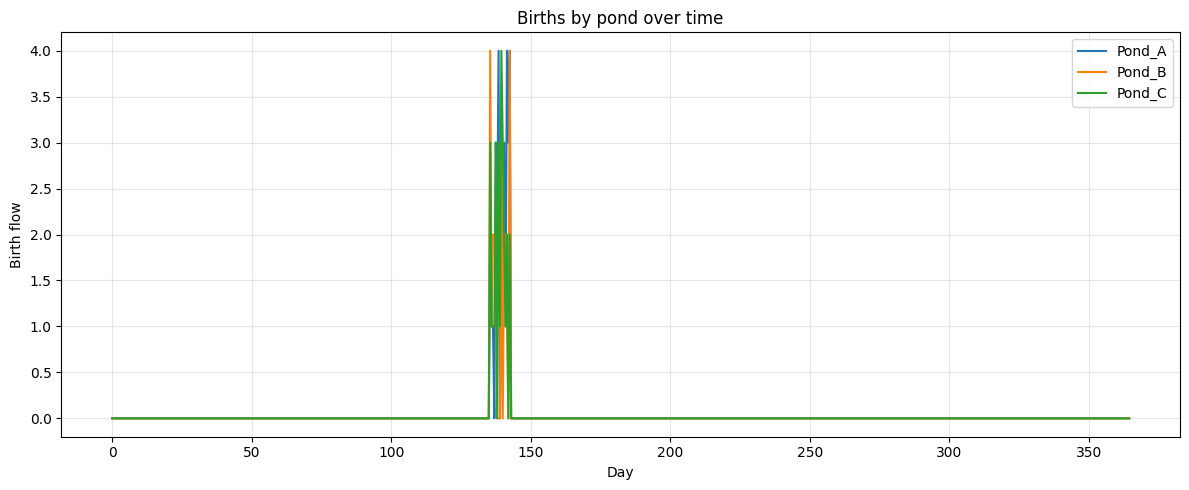

In [51]:
# ===========
# Diagnostics
# ===========

print("--- Total offspring around maturation (days 250-260) ---")
print(df_out.groupby("day")[["S_offspring", "I_offspring"]].sum().loc[250:260])

print("\n--- Total adults around maturation (days 250-260) ---")
print(df_out.groupby("day")[["R_a_adult", "R_c_adult"]].sum().loc[250:260])

print("\n--- Peak infected offspring by pond ---")
peak_I = (
    df_out.groupby("node")["I_offspring"]
    .max()
    .sort_values(ascending=False)
)
print(peak_I)


birth_df = (
    df_out.groupby(["day", "node"], as_index=False)["birth_exogenous → S_offspring"]
    .sum()
)

fig, ax = plt.subplots(figsize=(12, 5))
for pond in site_ids:
    sub = birth_df[birth_df["node"] == pond]
    ax.plot(sub["day"], sub["birth_exogenous → S_offspring"], label=pond)

ax.set_xlabel("Day")
ax.set_ylabel("Birth flow")
ax.set_title("Births by pond over time")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()